# Building a dataset for detecting attention patterns

### Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd

from src.data import load_wikitext, get_continuous_text, get_prompt_batch
from src.model import load_model, load_tokenizer, print_model_config


/Users/raffaeledagostino/anaconda3/envs/master_thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load dataset, tokenizer, and model
train_data = load_wikitext('train')
tokenizer = load_tokenizer()
model = load_model()

Loading weights: 100%|██████████| 398/398 [00:02<00:00, 185.93it/s, Materializing param=model.norm.weight]                              
Some parameters are on the meta device because they were offloaded to the disk.


In [ ]:
# printing model architecture
print_model_config(model)

NameError: name 'model' is not defined

: 

### 2. ecc

In [1]:
import sys
sys.path.insert(0, '..') # Aggiusta se il notebook non è nella root del progetto

import torch
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import Dict, Any, Optional

# --- Incolla qui (o importa) la definizione di HeadContext aggiornata ---
@dataclass
class HeadContext:
    model_name:     str
    layer_idx:      int
    head_idx:       int
    prompt_len:     int
    H_input:        torch.Tensor          # [seq_len, d_model]
    W_q:            torch.Tensor          # [head_dim, d_model]
    W_k:            torch.Tensor          # [head_dim, d_model]
    W_v:            torch.Tensor          # [head_dim, d_model]
    Q:              torch.Tensor          # [seq_len, head_dim]
    K:              torch.Tensor          # [seq_len, head_dim]
    attention_map:  torch.Tensor          # [seq_len, seq_len]
    rmsnorm_gamma:  Optional[torch.Tensor] = None
    cache:          Dict[str, Any] = field(default_factory=dict)

from core.features_library import FEATURE_REGISTRY, get_all_features

# --- Parametri sintetici compatibili con Qwen3-4B ---
SEQ_LEN  = 32   # prompt corto per il test
D_MODEL  = 2560
HEAD_DIM = 128

# Costruisci un contesto completamente sintetico
torch.manual_seed(42)

A_raw = torch.rand(SEQ_LEN, SEQ_LEN)
# Rendi la matrice causale e normalizzata come una vera softmax
mask = torch.tril(torch.ones(SEQ_LEN, SEQ_LEN))
A_raw = A_raw * mask
A_normalized = A_raw / A_raw.sum(dim=1, keepdim=True).clamp(min=1e-8)

ctx_test = HeadContext(
    model_name    = "synthetic_test",
    layer_idx     = 0,
    head_idx      = 0,
    prompt_len    = SEQ_LEN,
    H_input       = torch.randn(SEQ_LEN, D_MODEL),
    W_q           = torch.randn(HEAD_DIM, D_MODEL),
    W_k           = torch.randn(HEAD_DIM, D_MODEL),
    W_v           = torch.randn(HEAD_DIM, D_MODEL),
    Q             = torch.randn(SEQ_LEN, HEAD_DIM),
    K             = torch.randn(SEQ_LEN, HEAD_DIM),
    attention_map = A_normalized,
    rmsnorm_gamma = torch.ones(HEAD_DIM),  # gamma = 1 come default RMSNorm
)

# --- Esegui tutte le feature e mostra il risultato ---
results = get_all_features(ctx_test)

df_test = pd.DataFrame([results])
df_test.insert(0, 'layer', 0)
df_test.insert(1, 'head',  0)

print(f"Feature calcolate: {len(results)}")
print(f"Feature fallite (NaN): {sum(np.isnan(v) for v in results.values())}")
df_test.T  # Visualizza come tabella verticale

/Users/raffaeledagostino/anaconda3/envs/master_thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature calcolate: 31
Feature fallite (NaN): 0


,0
layer,0.000000
head,0.000000
effective_rank_Wq,127.192741
r95_Wq,121.000000
effective_rank_Wk,127.159813
r95_Wk,121.000000
effective_rank_Wv,127.189529
r95_Wv,121.000000
effective_rank_H,31.953442
r95_H,31.000000


In [5]:
# Cella 2 — Caricamento Qwen3-4B (Apple Silicon safe)
import sys
sys.path.insert(0, '..')  # aggiusta se necessario

import torch
from core.model import load_model, load_tokenizer, print_model_config

# Device: su M2 usiamo mps per le operazioni, 
# ma il caricamento avviene tramite device_map="auto"
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Device per inferenza: {DEVICE}")

MODEL_ID = "Qwen/Qwen3-4B"

tokenizer = load_tokenizer(MODEL_ID)

# load_model usa device_map="auto" internamente — compatibile con MPS
model = load_model(
    model_name=MODEL_ID,
    quantize_8bit=False,   # False = nessuna quantizzazione, come vuoi tu
    device_map="auto",
)
model.eval()

print_model_config(model)
print(f"\nParametri totali: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Device per inferenza: mps


Loading weights: 100%|██████████| 398/398 [00:02<00:00, 133.91it/s, Materializing param=model.norm.weight]                              
Some parameters are on the meta device because they were offloaded to the disk.


=== Model Configuration ===
Number of layers:          36
Attention heads (Q):       32
Key-Value heads:           8
Hidden size:               2560
Intermediate size (FFN):   9728
Vocab size:                151936
Max position embeddings:   40960
Head dim:                  128

Parametri totali: 4.02B


In [10]:
import gc
import sys
sys.path.insert(0, '..')  # o il path corretto alla root del progetto

from core.context import HeadContext
from core.features_library import FEATURE_REGISTRY, get_all_features

PROMPT = """This algorithm improves upon the Section C recommender by using Jaccard Node Similarity.
First, we compute similarity on a bipartite paper_keyword_graph to find past papers with the
highest keyword overlap to the new submission. Jaccard is ideal here, as its exact overlap
proportion penalises papers with excessive unrelated tags. The researchers who reviewed these
top-K similar papers form our expert seed set"""

# --- Tokenizzazione ---
inputs = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)
PROMPT_LEN = inputs.input_ids.shape[1]
print(f"Prompt length: {PROMPT_LEN} tokens")

# --- Parametri architetturali da config ---
NUM_LAYERS   = model.config.num_hidden_layers       # 36
NUM_Q_HEADS  = model.config.num_attention_heads     # 32
NUM_KV_HEADS = model.config.num_key_value_heads     # 8
HEAD_DIM     = model.config.hidden_size // NUM_Q_HEADS  # 128 (decoupled in Qwen3)
# Qwen3-4B ha head_dim=128 esplicitamente nella config, sovrascriviamo se presente
if hasattr(model.config, 'head_dim'):
    HEAD_DIM = model.config.head_dim

KV_GROUPS = NUM_Q_HEADS // NUM_KV_HEADS  # 4

print(f"Layers={NUM_LAYERS}, Q_heads={NUM_Q_HEADS}, KV_heads={NUM_KV_HEADS}, head_dim={HEAD_DIM}")

# --- Forward Pass ---
with torch.no_grad():
    outputs = model(
        **inputs,
        output_attentions=True,
        output_hidden_states=True,
    )

# --- Estrazione Layer 0 come test ---
LAYER_IDX = 0

H_layer = outputs.hidden_states[LAYER_IDX].squeeze(0)  # [seq_len, d_model]
A_layer = outputs.attentions[LAYER_IDX].squeeze(0)     # [num_q_heads, seq_len, seq_len]

# Recupera pesi dal modello (Qwen3 usa q_proj / k_proj / v_proj separati)
layer = model.model.layers[LAYER_IDX].self_attn
W_q_full = layer.q_proj.weight.detach().cpu().float()
W_k_full = layer.k_proj.weight.detach().cpu().float()
W_v_full = layer.v_proj.weight.detach().cpu().float()

# Recupera gamma di QK-Norm se presente (Qwen3 ce l'ha)
qk_norm_gamma = None
if hasattr(layer, 'q_norm'):
    qk_norm_gamma = layer.q_norm.weight.detach().cpu()

# Proietta Q e K on-the-fly su CPU
H_cpu = H_layer.cpu().float()
Q_full = H_cpu @ W_q_full.T  # [seq_len, num_q_heads * head_dim]
K_full = H_cpu @ W_k_full.T  # [seq_len, num_kv_heads * head_dim]

# Reshape per separare le teste
Q_heads = Q_full.view(PROMPT_LEN, NUM_Q_HEADS, HEAD_DIM).permute(1, 0, 2)   # [32, seq_len, head_dim]
K_heads = K_full.view(PROMPT_LEN, NUM_KV_HEADS, HEAD_DIM).permute(1, 0, 2)  # [8, seq_len, head_dim]
K_heads = K_heads.repeat_interleave(KV_GROUPS, dim=0)                        # [32, seq_len, head_dim]

# Reshape W_q e W_k per testa
W_q_heads = W_q_full.view(NUM_Q_HEADS, HEAD_DIM, -1)   # [32, head_dim, d_model]
W_k_heads = W_k_full.view(NUM_KV_HEADS, HEAD_DIM, -1)  # [8, head_dim, d_model]
W_v_heads = W_v_full.view(NUM_KV_HEADS, HEAD_DIM, -1)  # [8, head_dim, d_model]

# --- Loop su tutte le teste del Layer 0 ---
rows = []

for head_idx in range(NUM_Q_HEADS):
    kv_head_idx = head_idx // KV_GROUPS  # Mappa la testa Q alla testa KV corretta

    ctx = HeadContext(
        model_name    = MODEL_ID,
        layer_idx     = LAYER_IDX,
        head_idx      = head_idx,
        prompt_len    = PROMPT_LEN,
        H_input       = H_cpu,
        W_q           = W_q_heads[head_idx],
        W_k           = W_k_heads[kv_head_idx],
        W_v           = W_v_heads[kv_head_idx],
        Q             = Q_heads[head_idx],
        K             = K_heads[head_idx],
        attention_map = A_layer[head_idx].cpu().float(),
        rmsnorm_gamma = qk_norm_gamma,
        cache         = {},  # Cache fresca per ogni testa
    )

    row = {"model": MODEL_ID, "prompt_id": "test_001", "layer": LAYER_IDX, "head": head_idx}
    row.update(get_all_features(ctx))
    rows.append(row)

df_layer0 = pd.DataFrame(rows)

# Pulizia memoria
del A_layer, Q_full, K_full, Q_heads, K_heads
gc.collect()
if DEVICE == "mps":
    torch.mps.empty_cache()

print(f"Shape DataFrame: {df_layer0.shape}")
df_layer0.head()

Prompt length: 83 tokens
Layers=36, Q_heads=32, KV_heads=8, head_dim=128
Shape DataFrame: (32, 35)


,model,prompt_id,layer,head,effective_rank_Wq,r95_Wq,effective_rank_Wk,r95_Wk,effective_rank_Wv,r95_Wv,...,attention_sink_mass_1,attention_sink_mass_4,attention_entropy,attention_gini,max_attention_weight,attention_variance_per_query,query_key_sim_mean,attention_center_of_mass,effective_rank_A,r95_A
0,Qwen/Qwen3-4B,test_001,0,0,113.360413,111.0,122.341995,115.0,126.055634,119.0,...,0.060611,0.033519,237.568054,0.831386,1.0,0.001203,0.154092,0.679429,37.002060,46.0
1,Qwen/Qwen3-4B,test_001,0,1,115.118675,113.0,122.341995,115.0,126.055634,119.0,...,0.013398,0.003821,46.584362,0.983372,1.0,0.008853,0.157597,0.941749,79.030624,74.0
2,Qwen/Qwen3-4B,test_001,0,2,120.140739,111.0,122.341995,115.0,126.055634,119.0,...,0.000111,0.000036,11.641720,0.987650,1.0,0.011107,0.372086,0.993263,76.159691,71.0
3,Qwen/Qwen3-4B,test_001,0,3,111.996078,111.0,122.341995,115.0,126.055634,119.0,...,0.088087,0.030722,230.809418,0.834445,1.0,0.001634,0.258975,0.639548,47.991714,59.0
4,Qwen/Qwen3-4B,test_001,0,4,124.568443,117.0,123.263565,116.0,126.692337,120.0,...,0.071987,0.017475,195.644180,0.894181,1.0,0.002342,-0.067709,0.726942,49.408508,52.0


In [12]:
print(df_layer0.columns.tolist())

['model', 'prompt_id', 'layer', 'head', 'effective_rank_Wq', 'r95_Wq', 'effective_rank_Wk', 'r95_Wk', 'effective_rank_Wv', 'r95_Wv', 'effective_rank_H', 'r95_H', 'effective_rank_Q', 'r95_Q', 'effective_rank_K', 'r95_K', 'q_sim_consecutive', 'k_sim_consecutive', 'svd_alignment_H_Wq', 'svd_alignment_H_Wk', 'rmsnorm_gamma_norm', 'channel_variance_Wq', 'channel_variance_Wk', 'diagonal_mass_1', 'diagonal_mass_5', 'attention_sink_mass_1', 'attention_sink_mass_4', 'attention_entropy', 'attention_gini', 'max_attention_weight', 'attention_variance_per_query', 'query_key_sim_mean', 'attention_center_of_mass', 'effective_rank_A', 'r95_A']


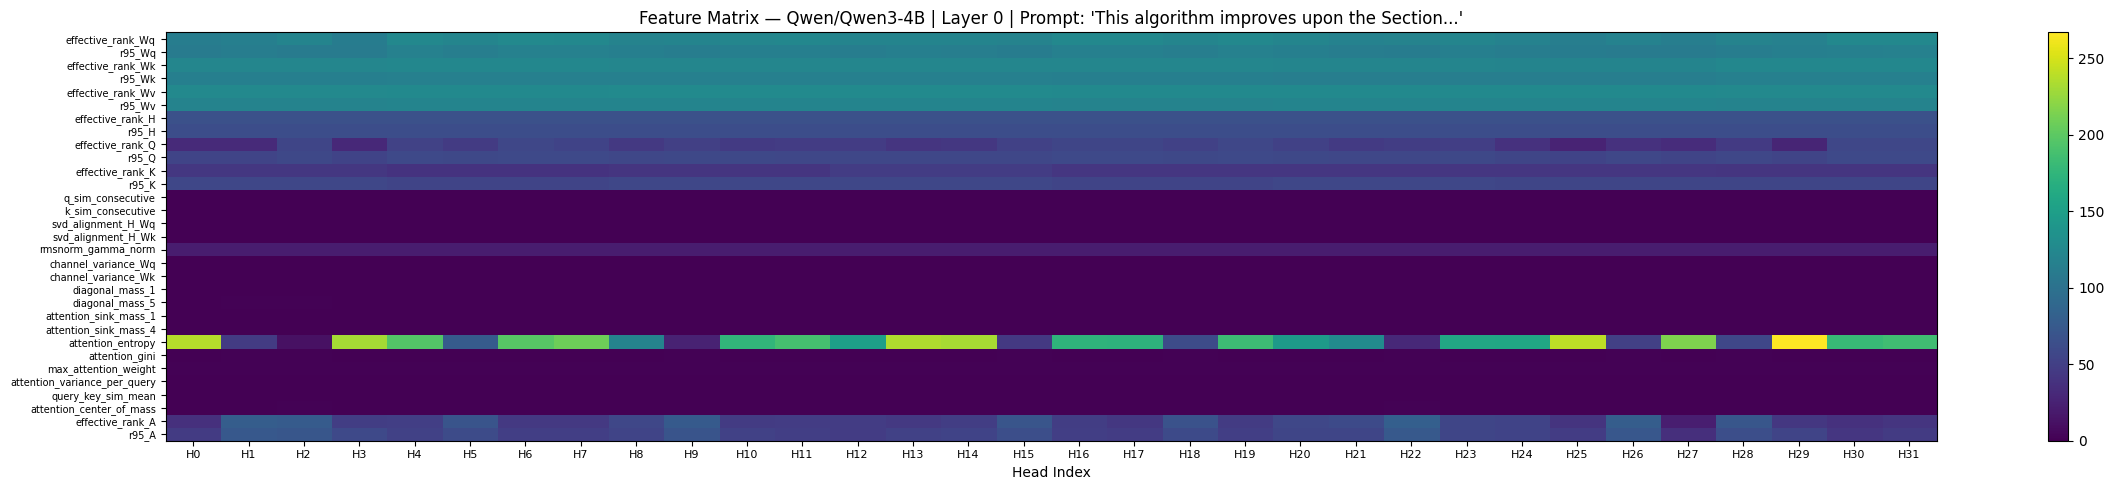

In [11]:
import matplotlib.pyplot as plt

# Heatmap delle feature per le 32 teste del layer 0
feature_cols = [c for c in df_layer0.columns if c not in ['model', 'prompt_id', 'layer', 'head']]
data = df_layer0[feature_cols].set_index(df_layer0['head'])

fig, ax = plt.subplots(figsize=(24, 5))
im = ax.imshow(data.T.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(NUM_Q_HEADS))
ax.set_xticklabels([f"H{i}" for i in range(NUM_Q_HEADS)], fontsize=8)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols, fontsize=7)
ax.set_xlabel("Head Index")
ax.set_title(f"Feature Matrix — {MODEL_ID} | Layer {LAYER_IDX} | Prompt: '{PROMPT[:40]}...'")
plt.colorbar(im, ax=ax)
plt.tight_layout()
#plt.savefig("layer0_features.png", dpi=150)
plt.show()